In [1]:
import torch

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found! Go to Runtime → Change runtime type → T4 GPU")

GPU detected: Tesla T4
   VRAM: 15.6 GB


In [2]:
%%capture
!pip install yt-dlp openai-whisper pyannote.audio pydub python-dotenv
!pip install -q torch torchaudio --index-url https://download.pytorch.org/whl/cu118
!apt-get install -y ffmpeg -q
print("Done!")

In [3]:
%%capture
!pip install -q \
    "numpy==1.26.4" \
    "scipy==1.12.0" \
    "torchmetrics==1.3.2" \
    "lightning==2.2.5" \
    "pyannote.audio==3.1.1" \
    "torch==2.2.2" \
    "torchaudio==2.2.2" \
    --index-url https://download.pytorch.org/whl/cu118
print("Done!")

In [4]:
%%capture
!pip install faster-whisper

In [1]:
from google.colab import userdata

try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    print("HF_TOKEN loaded")
except Exception:
    HF_TOKEN = "hf_your_token_here"  # fallback

HF_TOKEN loaded


In [2]:
import subprocess, json, time, os, torch

os.makedirs("outputs", exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def download_video(url, out_path="outputs/video.mp4"):
    subprocess.run(["yt-dlp", "-f", "bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4",
                    "-o", out_path, "--merge-output-format", "mp4", url], check=True)
    return out_path

def extract_audio(video_path, audio_path="outputs/audio.wav"):
    subprocess.run(["ffmpeg", "-y", "-i", video_path,
                    "-ac", "1", "-ar", "16000", "-vn", audio_path],
                   check=True, capture_output=True)
    return audio_path

def transcribe_audio(audio_path, model_size="base"):
    from faster_whisper import WhisperModel

    # device_index=0 means first GPU
    model = WhisperModel(model_size, device=DEVICE, compute_type="float16")

    segments, info = model.transcribe(
        audio_path,
        beam_size=5,
        vad_filter=True,          # ← skips silence, massive speedup
        vad_parameters=dict(min_silence_duration_ms=500)
    )

    print(f"Detected language: {info.language} ({info.language_probability:.0%})")

    # Convert to same format as openai-whisper
    result_segments = []
    full_text = ""
    for seg in segments:
        result_segments.append({
            "start": seg.start,
            "end": seg.end,
            "text": seg.text.strip()
        })
        full_text += seg.text

    return {"text": full_text, "segments": result_segments}
def save_transcript(transcript, path):
    with open(path, "w") as f:
        json.dump(transcript, f, indent=2)

def diarize(audio_path, hf_token):
    from pyannote.audio import Pipeline
    pipeline = Pipeline.from_pretrained(
        "pyannote/speaker-diarization-3.1", token=hf_token)
    pipeline.to(torch.device(DEVICE))
    diarization = pipeline(audio_path, num_workers=4)

    # The actual Annotation is inside .speaker_diarization
    annotation = diarization.speaker_diarization
    segments = []
    for t, _, s in annotation.itertracks(yield_label=True):
        segments.append({"start": t.start, "end": t.end, "speaker": s})

    return segments

def align(transcript, speaker_segments):
    aligned = []
    for seg in transcript.get("segments", []):
        best_speaker, best_overlap = "UNKNOWN", 0.0
        for sp in speaker_segments:
            overlap = max(0, min(seg["end"], sp["end"]) - max(seg["start"], sp["start"]))
            if overlap > best_overlap:
                best_overlap, best_speaker = overlap, sp["speaker"]
        aligned.append({"start": seg["start"], "end": seg["end"],
                        "speaker": best_speaker, "text": seg["text"].strip()})
    return aligned

def save_json(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

print(f"Ready on {DEVICE}")

Ready on cuda


In [3]:
youtube_url = input("Enter YouTube URL: ").strip()
total_start = time.time()

print("[1/5] Downloading..."); t = time.time()
video_path = download_video(youtube_url)
print(f"      {time.time()-t:.1f}s")

print("[2/5] Extracting audio..."); t = time.time()
audio_path = extract_audio(video_path)
print(f"      {time.time()-t:.1f}s")


Enter YouTube URL: https://youtu.be/lacFcgcHx6I?si=N_TzMwkZDqjZKtZy
[1/5] Downloading...
      97.7s
[2/5] Extracting audio...
      20.5s


In [4]:
print("[3/5] Transcribing (Whisper on GPU)..."); t = time.time()
transcript = transcribe_audio(audio_path, model_size="base")
save_transcript(transcript, "outputs/transcript.json")
print(f"      {time.time()-t:.1f}s")

[3/5] Transcribing (Whisper on GPU)...
Detected language: en (72%)
      300.8s


In [5]:
print("[4/5] Diarizing (GPU)..."); t = time.time()
speaker_segments = diarize(audio_path, HF_TOKEN)
print(f"      {time.time()-t:.1f}s | {len(speaker_segments)} segments")

[4/5] Diarizing (GPU)...


config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/audio/pipelines/speaker_diarization.py:567: UserWarning: Ignoring unexpected keyword arguments: num_workers
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


      2325.9s | 2265 segments


In [6]:
print("[5/5] Aligning..."); t = time.time()
final_output = align(transcript, speaker_segments)
save_json(final_output, "outputs/final.json")
print(f"      {time.time()-t:.1f}s")


[5/5] Aligning...
      4.3s


In [7]:
print(f"\nTotal: {time.time()-total_start:.1f}s → outputs/final.json")


Total: 2762.5s → outputs/final.json


In [8]:
import pandas as pd

df = pd.DataFrame(final_output)
df["start"] = df["start"].round(2)
df["end"] = df["end"].round(2)
print(f"Speakers: {df['speaker'].unique()}")
df[["start", "end", "speaker", "text"]].head(20)

Speakers: <ArrowStringArray>
['SPEAKER_03', 'SPEAKER_01', 'SPEAKER_00', 'SPEAKER_02', 'UNKNOWN']
Length: 5, dtype: str


,start,end,speaker,text
0,0.24,2.24,SPEAKER_03,So there is a natural brain.
1,2.24,3.24,SPEAKER_03,Yes.
2,3.24,8.24,SPEAKER_01,That's what you imagine when you see a human b...
3,8.24,9.24,SPEAKER_03,Is my brain like this?
4,9.24,11.24,SPEAKER_01,Your brain is bigger than this.
5,11.24,13.24,SPEAKER_01,It's about one and a half kilograms.
6,13.24,15.24,SPEAKER_01,"If I gave you a rat brain, okay."
7,15.24,17.24,SPEAKER_01,So now that's a rat brain.
8,17.24,22.37,SPEAKER_03,What can this preserved brain tell you about a...
9,22.37,26.68,SPEAKER_01,"Okay, so you can cut this into sections."


In [9]:
from google.colab import files
files.download("outputs/final.json")
files.download("outputs/transcript.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
def merge_segments(segments):
    if not segments:
        return segments

    merged = [segments[0].copy()]

    for seg in segments[1:]:
        last = merged[-1]
        if seg["speaker"] == last["speaker"]:
            # Same speaker — extend and combine text
            last["end"] = seg["end"]
            last["text"] = last["text"] + " " + seg["text"]
        else:
            merged.append(seg.copy())

    return merged

merged_output = merge_segments(final_output)
save_json(merged_output, "outputs/final_merged.json")

print(f"Before: {len(final_output)} segments")
print(f"After:  {len(merged_output)} segments")

Before: 2668 segments
After:  423 segments


In [11]:
from transformers import pipeline as hf_pipeline
import json

# Load merged transcript
with open("outputs/final_merged.json") as f:
    segments = json.load(f)

# Load emotion classifier (runs on GPU)
emotion_classifier = hf_pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1,
    device=0 if torch.cuda.is_available() else -1
)

sentiment_classifier = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

print("Running emotion detection...")
for seg in segments:
    text = seg["text"][:512]  # transformer max length

    emotion_result = emotion_classifier(text)[0][0]
    seg["emotion"] = emotion_result["label"]
    seg["emotion_score"] = round(emotion_result["score"], 3)

    sentiment_result = sentiment_classifier(text)[0]
    score = sentiment_result["score"]
    seg["sentiment_score"] = round(
        score if sentiment_result["label"] == "POSITIVE" else -score, 3
    )

save_json(segments, "outputs/final_with_emotions.json")
print(f"Done! Processed {len(segments)} segments")

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Running emotion detection...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done! Processed 423 segments


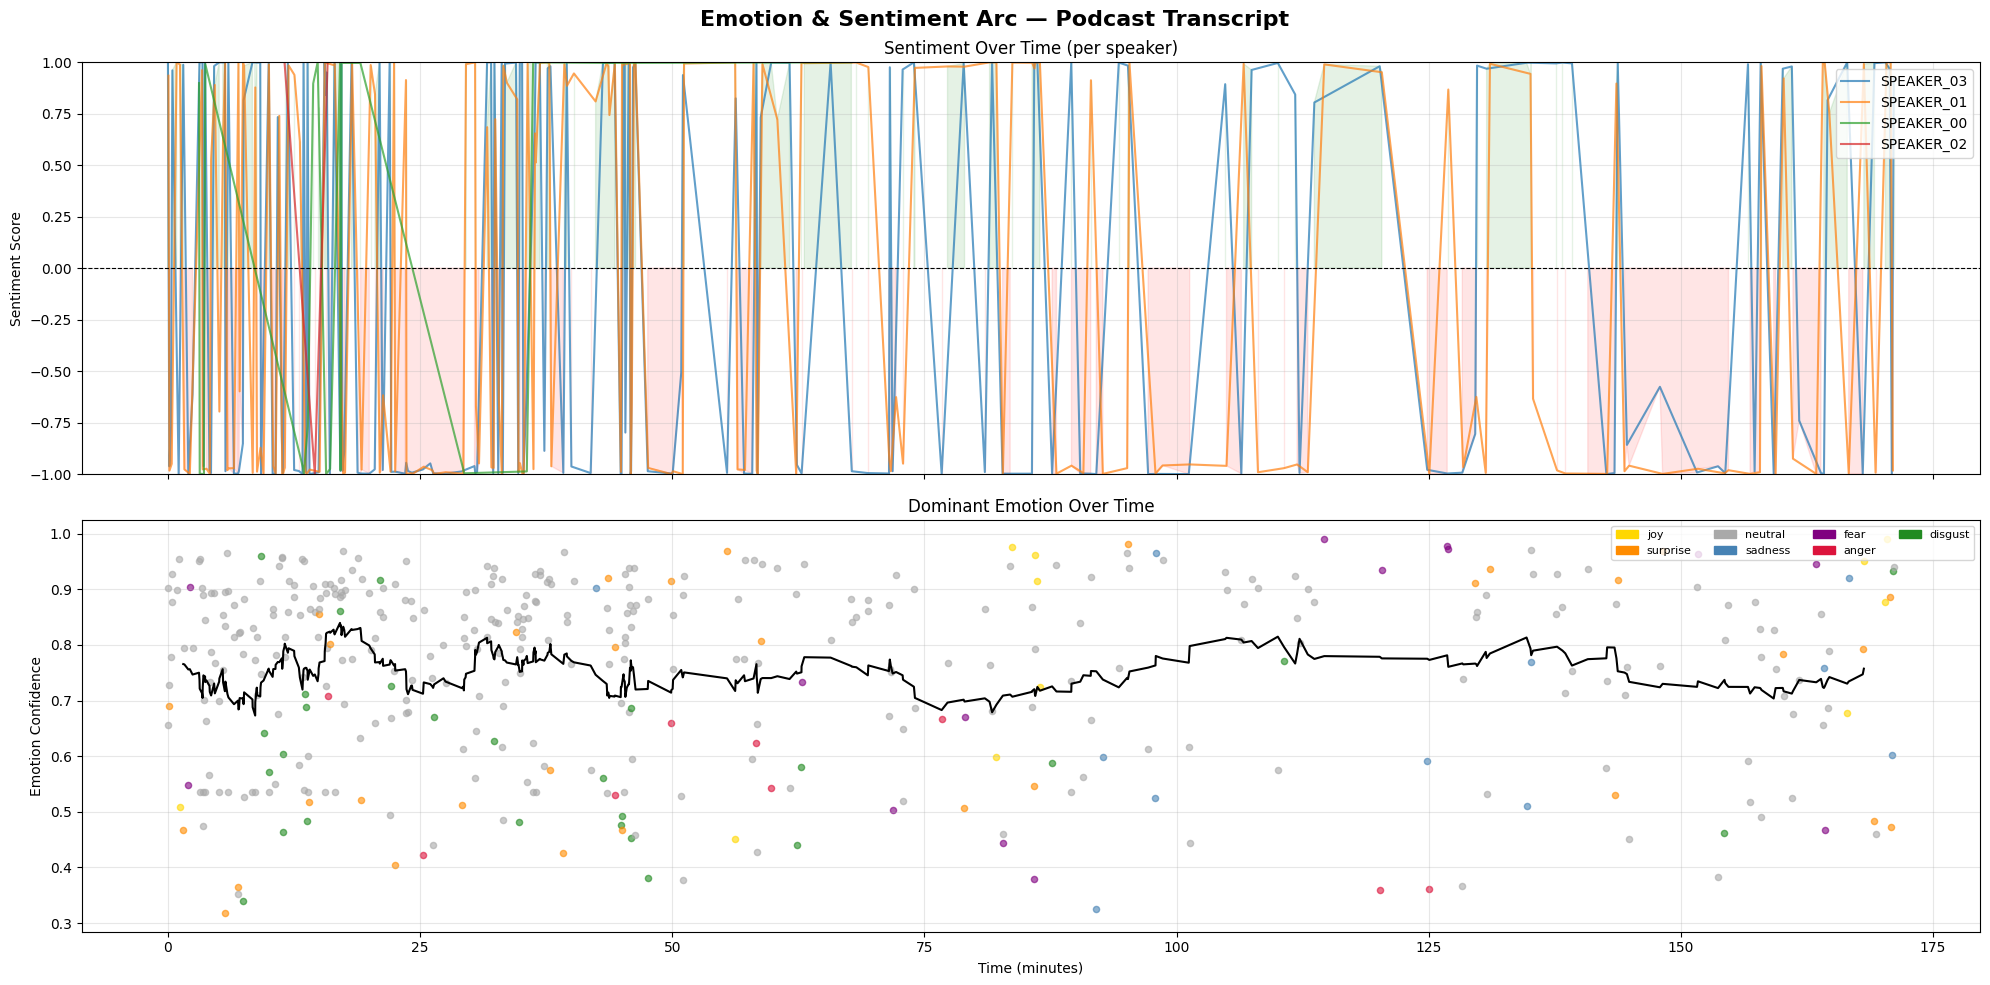

Saved → outputs/emotion_arc.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.DataFrame(segments)
df["minutes"] = (df["start"] / 60).round(2)

# Emotion color map
emotion_colors = {
    "joy":      "#FFD700",
    "surprise": "#FF8C00",
    "neutral":  "#A9A9A9",
    "sadness":  "#4682B4",
    "fear":     "#800080",
    "anger":    "#DC143C",
    "disgust":  "#228B22",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
fig.suptitle("Emotion & Sentiment Arc — Podcast Transcript", fontsize=16, fontweight="bold")

# Plot 1: Sentiment arc per speaker
for speaker in df["speaker"].unique():
    if speaker == "UNKNOWN":
        continue
    sp_df = df[df["speaker"] == speaker]
    ax1.plot(sp_df["minutes"], sp_df["sentiment_score"],
             label=speaker, alpha=0.7, linewidth=1.5)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.fill_between(df["minutes"], df["sentiment_score"], 0,
                 where=df["sentiment_score"] > 0, alpha=0.1, color="green")
ax1.fill_between(df["minutes"], df["sentiment_score"], 0,
                 where=df["sentiment_score"] < 0, alpha=0.1, color="red")
ax1.set_ylabel("Sentiment Score")
ax1.set_ylim(-1, 1)
ax1.legend(loc="upper right")
ax1.set_title("Sentiment Over Time (per speaker)")
ax1.grid(alpha=0.3)

# Plot 2: Emotion scatter
for _, row in df.iterrows():
    color = emotion_colors.get(row["emotion"], "#A9A9A9")
    ax2.scatter(row["minutes"], row["emotion_score"],
                color=color, alpha=0.6, s=20)

# Smooth emotion intensity line
ax2.plot(df["minutes"],
         df["emotion_score"].rolling(20, center=True).mean(),
         color="black", linewidth=1.5, label="Smoothed intensity")

legend_patches = [mpatches.Patch(color=c, label=e)
                  for e, c in emotion_colors.items()]
ax2.legend(handles=legend_patches, loc="upper right", ncol=4, fontsize=8)
ax2.set_ylabel("Emotion Confidence")
ax2.set_xlabel("Time (minutes)")
ax2.set_title("Dominant Emotion Over Time")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/emotion_arc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/emotion_arc.png")

In [13]:
print("Top 5 Most Intense Moments:\n")
top = df.nlargest(5, "emotion_score")[["minutes", "speaker", "emotion", "emotion_score", "text"]]
for _, row in top.iterrows():
    print(f"  {row['minutes']:.1f} min | {row['speaker']} | {row['emotion'].upper()} ({row['emotion_score']:.2f})")
    print(f"  \"{row['text'][:100]}\"")
    print()

Top 5 Most Intense Moments:

  114.6 min | SPEAKER_01 | FEAR (0.99)
  "through and what is not anxiety so anxiety so there's fear right which is the underlying basis event"

  170.4 min | SPEAKER_01 | JOY (0.99)
  "a lot of fun and thoroughly enjoyed it that was great fun"

  95.2 min | SPEAKER_03 | SURPRISE (0.98)
  "But all 90, if I'm like, how this entire generation is feeling, I'm surprised. I think part of it. W"

  126.8 min | SPEAKER_03 | FEAR (0.98)
  "anxiety like where does it happen does it happen inside my body or brain both so the where does"

  83.7 min | SPEAKER_01 | JOY (0.98)
  "Okay. I would first say find out what you thoroughly have enjoyed doing. Okay. First, so first you h"

